# DDSP Model Evaluation

This notebook loads a trained DDSP model from a training directory,
takes random chunks from a dataset, runs a forward pass, and evaluates
reconstruction quality via:

- **MSE** (mean squared error)
- **Multi-resolution spectral loss** (MRSTFT via `auraloss`)
- **Overlaid magnitude spectra** (original vs. synthesised)
- **Waveform comparison** plots
- **Playback** of original and synthesised audio (IPython widgets)

In [1]:
# Configuration - edit these paths

# MODEL_TRAINING_DIR = "../training/synth/violin_complex_sine"
# MODEL_TRAINING_DIR = "../training/synth/violin_hybrid_bendable"
MODEL_TRAINING_DIR = "../training/synth/violin_hybrid_harmonic3"
DATASET_PATH       = "/mnt/mariadata/datasets/ddsp-vae/instruments/violin/processed"

# Audio parameters (must match the config used for training)
SAMPLE_RATE        = 22050
CHUNK_DURATION_S   = 2.0
RESAMPLING_FACTOR  = 32

# How many random chunks to evaluate
NUM_SAMPLES        = 3

DEVICE = "cuda"  # "cuda" or "cpu"

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import auraloss.freq
from IPython.display import Audio, display

from ddsp import DDSP, AudioFeatureDataset
from ddsp.utils import find_checkpoint
from ddsp.interfaces import ControlField, ControlSpace, build_control_space

sns.set_theme(style="darkgrid", context="notebook", palette="muted")
torch.set_grad_enabled(False)

print(f"PyTorch {torch.__version__}  |  CUDA available: {torch.cuda.is_available()}")

PyTorch 2.1.2+cu121  |  CUDA available: True


## 1 - Load the trained model

In [3]:
import yaml

checkpoint_path = find_checkpoint(MODEL_TRAINING_DIR, typ="best")
print(f"Loading checkpoint: {checkpoint_path}")

# Reconstruct ControlSpace from checkpoint hyperparameters + training config YAML
ckpt = torch.load(checkpoint_path, map_location="cpu")
hparams = ckpt.get("hyper_parameters", {})
feature_dim = int(hparams.get("feature_dim", 0))
latent_size = int(hparams.get("latent_size", 0))
config_name = hparams.get("config_name", None)
synth_configs = hparams.get("synth_configs", [])

# Build ControlSpace from the training config YAML when available.
# HarmonicSynth needs individually-named feature fields (pitch, loudness)
# so a generic blob field won't work.
config_path = None
if config_name:
    candidate = os.path.join("..", "configs", f"{config_name}.yaml")
    if os.path.exists(candidate):
        config_path = candidate

if config_path is not None:
    print(f"Building ControlSpace from config: {config_path}")
    with open(config_path) as f:
        cfg = yaml.safe_load(f)
    model_control_space = build_control_space(cfg["model"]["control_space"])
else:
    print("WARNING: Config YAML not found — using minimal ControlSpace (may fail for HarmonicSynth).")
    fields = []
    if feature_dim > 0:
        fields.append(ControlField(name="features", dim=feature_dim, source="feature", extractor=None))
    if latent_size > 0:
        fields.append(ControlField(name="latents", dim=latent_size, source="latent", extractor=None))
    model_control_space = ControlSpace(tuple(fields))

ddsp = DDSP.load_from_checkpoint(
    checkpoint_path,
    strict=False,
    device=DEVICE,
    control_space=model_control_space,
).to(DEVICE)
ddsp.eval()

print(f"Model loaded  |  fs={ddsp.fs}  resampling_factor={ddsp.resampling_factor}")
print(f"  feature_dim={ddsp.feature_dim}  latent_size={ddsp.latent_size}")
print(f"  config_name={config_name}")
print(f"  synths: {[s.jit_name for s in ddsp.synths]}")
print(f"  total synth params: {ddsp._total_synth_params}")


Loading checkpoint: ../training/synth/violin_hybrid_harmonic3/best.ckpt
Building ControlSpace from config: ../configs/experiment_hybrid_harmonic.yaml
Building synthesizers..., resampling_factor: 32


/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torchaudio/functional/functional.py:584: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
/home/btadeusz/miniconda3/envs/ddsp/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:30: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


Model loaded  |  fs=22050  resampling_factor=32
  feature_dim=2  latent_size=2
  config_name=experiment_hybrid_harmonic
  synths: ['HarmonicSynth', 'FilteredNoiseSynth']
  total synth params: 165


## 2 - Load the dataset

In [4]:
# Reuse the control space built from YAML in the model-loading cell.
# It already has the proper feature fields with extractors (loudness, pitch, etc.).
# AudioFeatureDataset uses it to extract features; latent fields are ignored.

n_signal = int(SAMPLE_RATE * CHUNK_DURATION_S)

dataset = AudioFeatureDataset(
    dataset_path=DATASET_PATH,
    n_signal=n_signal,
    sampling_rate=SAMPLE_RATE,
    resampling_factor=RESAMPLING_FACTOR,
    control_space=model_control_space,
    device=DEVICE,
)

print(f"Dataset loaded: {len(dataset)} chunks  |  n_signal={n_signal}  ({CHUNK_DURATION_S}s @ {SAMPLE_RATE} Hz)")
print(f"  feature_dim={model_control_space.feature_dim}  latent_dim={model_control_space.latent_dim}")


Loading from cache: /mnt/mariadata/datasets/ddsp-vae/instruments/violin/audio_cache_64f89a1e.lmdb


/home/btadeusz/code/ddsp_vae/ddsp/audio_feature_dataset.py:191: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  audio_cpu[pos:pos+n_samps] = torch.from_numpy(a_arr)


Dataset loaded: 1496 chunks  |  n_signal=44100  (2.0s @ 22050 Hz)
  feature_dim=2  latent_dim=2


## 3 - Forward pass and metrics

In [5]:
# Build the multi-resolution STFT loss (same FFT sizes as training)
fft_sizes = np.array([2053, 1021, 509, 257, 129, 65, 33])
mrstft_loss_fn = auraloss.freq.MultiResolutionSTFTLoss(
    fft_sizes=fft_sizes.tolist(),
    hop_sizes=(fft_sizes // 4).tolist(),
    win_lengths=fft_sizes.tolist(),
    perceptual_weighting=True,
    sample_rate=SAMPLE_RATE,
).to(DEVICE)


feature_fields = [f for f in model_control_space.fields if f.source == "feature"]
feature_slices = {}
offset = 0
for f in feature_fields:
    feature_slices[f.name] = slice(offset, offset + f.dim)
    offset += f.dim


def _find_feature_name(preferred_tokens):
    for name in feature_slices.keys():
        lname = name.lower()
        if any(tok in lname for tok in preferred_tokens):
            return name
    return None


pitch_feature_name = _find_feature_name(["pitch", "f0", "fundamental"] )
loudness_feature_name = _find_feature_name(["loudness", "rms", "amplitude", "energy"])

print(f"Pitch feature field: {pitch_feature_name}")
print(f"Loudness feature field: {loudness_feature_name}")


def evaluate_sample(idx: int):
    """Run a single dataset chunk through the model and return metrics + tensors."""
    audio, features = dataset[idx]
    # audio:    [T_audio]          (on DEVICE)
    # features: [T_ctl, D_feat]    (on DEVICE)

    x_audio   = audio.unsqueeze(0).float()       # [1, T_audio]
    x_feat    = features.unsqueeze(0).float()     # [1, T_ctl, D_feat]

    # Forward pass (autoencoder)
    y_audio = ddsp(x_audio, x_feat)      # [1, 1, T_audio']
    y_audio = y_audio.squeeze(0).float() # [1, T_audio']

    # Align lengths
    T = min(x_audio.shape[-1], y_audio.shape[-1])
    x = x_audio[..., :T]
    y = y_audio[..., :T]

    # MSE
    mse = torch.nn.functional.mse_loss(y, x).item()

    # MRSTFT
    x_3d = x.unsqueeze(0) if x.dim() == 2 else x
    y_3d = y.unsqueeze(0) if y.dim() == 2 else y
    mrstft = mrstft_loss_fn(y_3d.float(), x_3d.float()).item()

    pitch_env = None
    if pitch_feature_name is not None:
        p = x_feat[0, :, feature_slices[pitch_feature_name]]
        pitch_env = (p.mean(dim=-1) if p.dim() == 2 else p).detach().cpu().numpy()

    loudness_env = None
    if loudness_feature_name is not None:
        l = x_feat[0, :, feature_slices[loudness_feature_name]]
        loudness_env = (l.mean(dim=-1) if l.dim() == 2 else l).detach().cpu().numpy()

    return {
        "idx": idx,
        "mse": mse,
        "mrstft": mrstft,
        "x": x.squeeze().cpu().numpy(),
        "y": y.squeeze().cpu().numpy(),
        "pitch_env": pitch_env,
        "loudness_env": loudness_env,
    }


# Pick random samples
rng = np.random.default_rng(42)
sample_indices = rng.choice(len(dataset), size=min(NUM_SAMPLES, len(dataset)), replace=False)

results = []
for idx in sample_indices:
    r = evaluate_sample(int(idx))
    results.append(r)
    print(f"Sample {r['idx']:>4d}  |  MSE = {r['mse']:.6f}  |  MRSTFT = {r['mrstft']:.4f}")

avg_mse    = np.mean([r["mse"] for r in results])
avg_mrstft = np.mean([r["mrstft"] for r in results])
print(f"{'=' * 60}")
print(f"Average      |  MSE = {avg_mse:.6f}  |  MRSTFT = {avg_mrstft:.4f}")

Pitch feature field: pitch
Loudness feature field: loudness
Sample  979  |  MSE = 0.014076  |  MRSTFT = 0.7890
Sample  133  |  MSE = 0.039366  |  MRSTFT = 0.6067
Sample 1157  |  MSE = 0.000629  |  MRSTFT = 0.6506
Average      |  MSE = 0.018024  |  MRSTFT = 0.6821


## 4 - Spectrum comparison (original vs. synthesised)

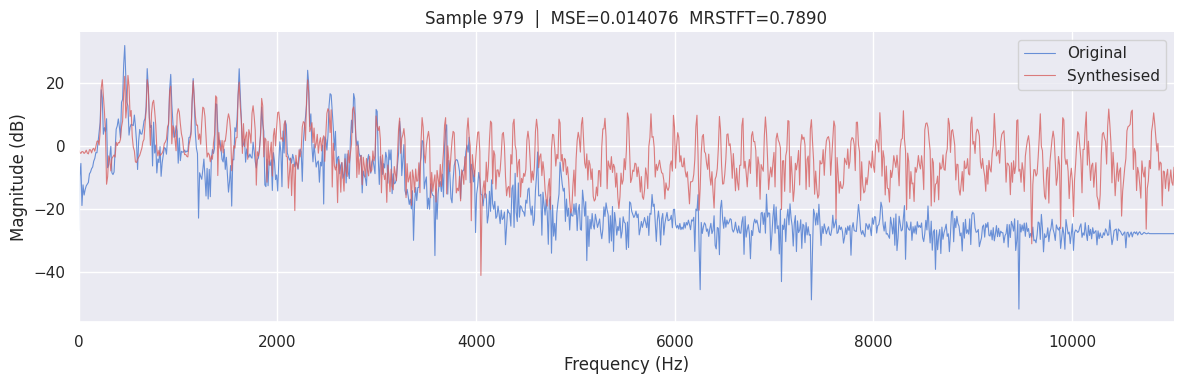

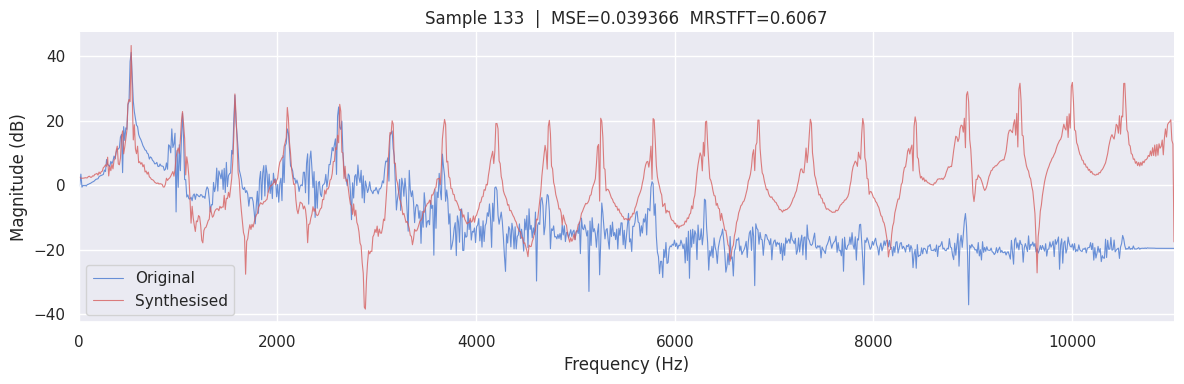

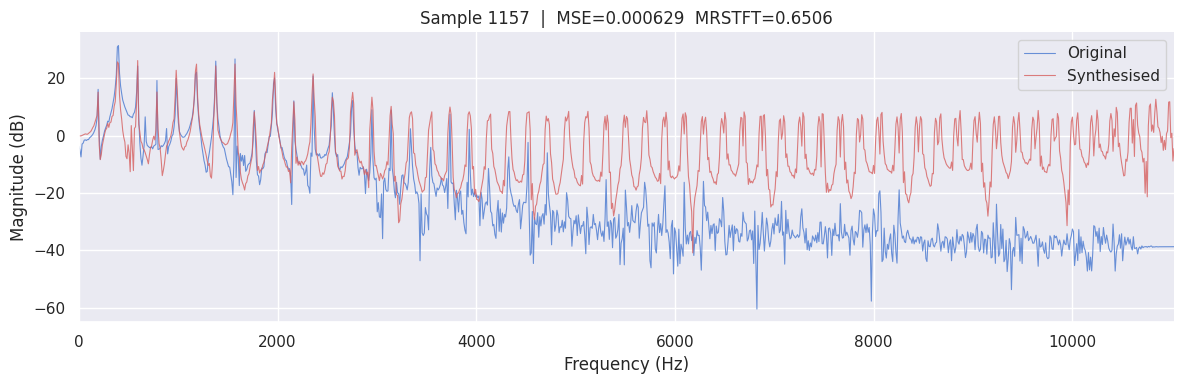

In [6]:
def plot_spectrum(x: np.ndarray, y: np.ndarray, sr: int, title: str = ""):
    """Plot overlaid magnitude spectra of original (x) and synthesised (y)."""
    n_fft = 2048
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / sr)

    X = np.abs(np.fft.rfft(x, n=n_fft))
    Y = np.abs(np.fft.rfft(y, n=n_fft))

    # Convert to dB
    X_db = 20 * np.log10(X + 1e-8)
    Y_db = 20 * np.log10(Y + 1e-8)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(freqs, X_db, color=sns.color_palette()[0], alpha=0.8, linewidth=0.8, label="Original")
    ax.plot(freqs, Y_db, color=sns.color_palette()[3], alpha=0.8, linewidth=0.8, label="Synthesised")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(title or "Magnitude Spectrum")
    ax.legend(frameon=True, fancybox=True)
    ax.set_xlim(0, sr / 2)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()


for r in results:
    plot_spectrum(r["x"], r["y"], SAMPLE_RATE,
                 title=f"Sample {r['idx']}  |  MSE={r['mse']:.6f}  MRSTFT={r['mrstft']:.4f}")

## 5 - Waveform comparison

/tmp/ipykernel_2417036/795639215.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


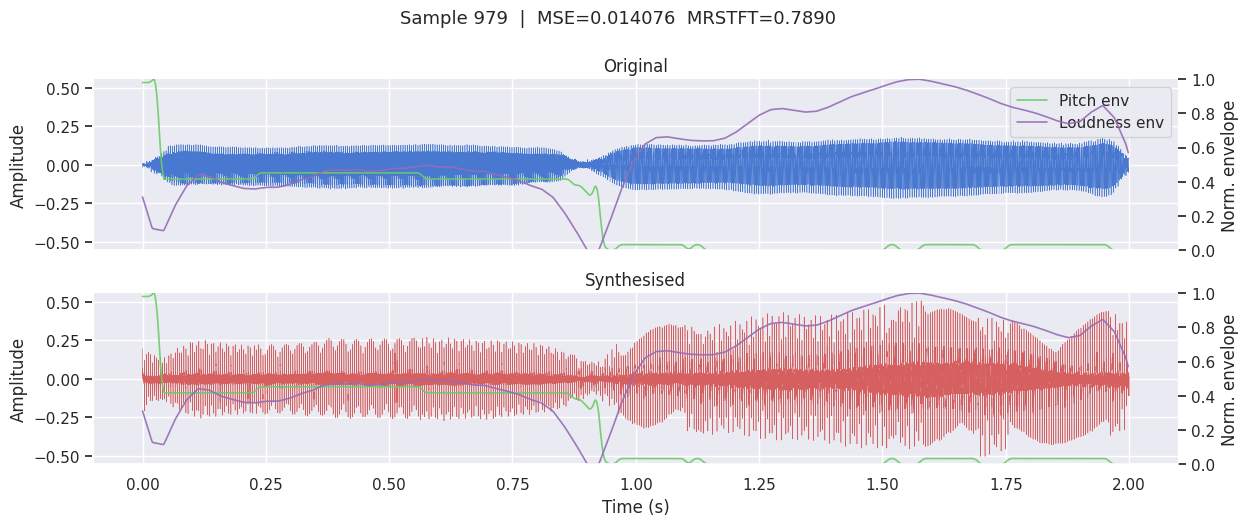

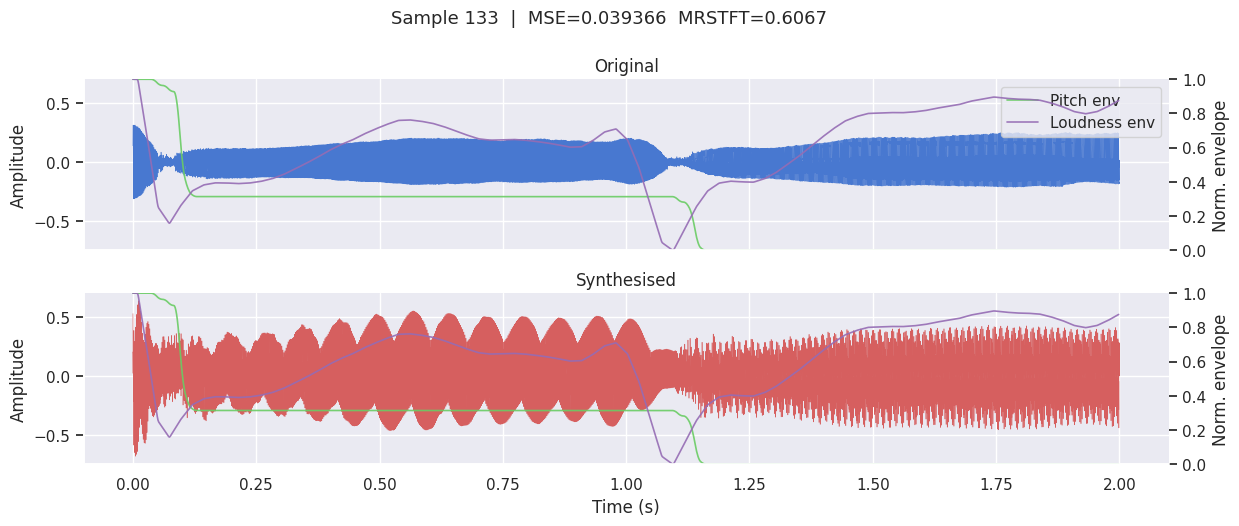

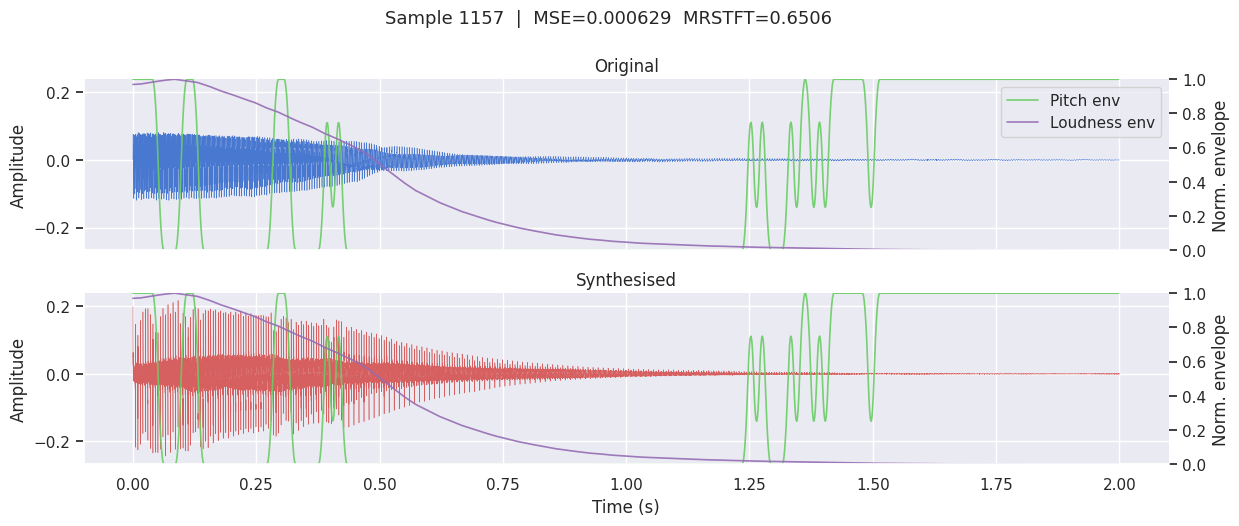

In [7]:
def plot_waveforms(
    x: np.ndarray,
    y: np.ndarray,
    sr: int,
    pitch_env: np.ndarray | None = None,
    loudness_env: np.ndarray | None = None,
    title: str = "",
):
    """Plot original and synthesised waveforms with optional pitch/loudness envelopes."""
    t = np.arange(len(x)) / sr

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 5),
        sharex=True,
        gridspec_kw={"hspace": 0.25},
    )

    wave_color_original = sns.color_palette()[0]
    wave_color_synth = sns.color_palette()[3]

    axes[0].plot(t, x, color=wave_color_original, linewidth=0.4, label="Waveform")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Original")

    axes[1].plot(t, y, color=wave_color_synth, linewidth=0.4, label="Waveform")
    axes[1].set_ylabel("Amplitude")
    axes[1].set_title("Synthesised")
    axes[1].set_xlabel("Time (s)")

    # Sync y-axis limits
    ymin = min(x.min(), y.min()) * 1.1
    ymax = max(x.max(), y.max()) * 1.1
    for ax in axes:
        ax.set_ylim(ymin, ymax)

    def _normalize(v: np.ndarray):
        v = np.asarray(v, dtype=np.float32)
        span = float(v.max() - v.min())
        if span < 1e-8:
            return np.zeros_like(v)
        return (v - v.min()) / span

    env_len = None
    if pitch_env is not None:
        env_len = len(pitch_env)
    elif loudness_env is not None:
        env_len = len(loudness_env)

    if env_len is not None and env_len > 0:
        t_env = np.linspace(0.0, len(x) / sr, num=env_len, endpoint=False)
        env_handles = []
        env_labels = []

        for ax in axes:
            ax_env = ax.twinx()
            ax_env.set_ylim(0.0, 1.0)
            ax_env.set_ylabel("Norm. envelope")
            ax_env.grid(False)

            if pitch_env is not None:
                hp, = ax_env.plot(
                    t_env,
                    _normalize(pitch_env),
                    color=sns.color_palette()[2],
                    linewidth=1.2,
                    alpha=0.9,
                    label="Pitch env",
                )
                if not env_handles:
                    env_handles.append(hp)
                    env_labels.append("Pitch env")

            if loudness_env is not None:
                hl, = ax_env.plot(
                    t_env,
                    _normalize(loudness_env),
                    color=sns.color_palette()[4],
                    linewidth=1.2,
                    alpha=0.9,
                    label="Loudness env",
                )
                if len(env_labels) < (2 if pitch_env is not None else 1):
                    env_handles.append(hl)
                    env_labels.append("Loudness env")

        if env_handles:
            axes[0].legend(env_handles, env_labels, loc="upper right", frameon=True, fancybox=True)

    fig.suptitle(title or "Waveform comparison", fontsize=13, y=1.02)
    sns.despine(fig=fig)
    plt.tight_layout()
    plt.show()


for r in results:
    plot_waveforms(
        r["x"],
        r["y"],
        SAMPLE_RATE,
        pitch_env=r.get("pitch_env"),
        loudness_env=r.get("loudness_env"),
        title=f"Sample {r['idx']}  |  MSE={r['mse']:.6f}  MRSTFT={r['mrstft']:.4f}",
    )

## 6 - Audio playback

In [8]:
for r in results:
    print(f"\n=== Sample {r['idx']} ===")
    print("Original:")
    display(Audio(r["x"], rate=SAMPLE_RATE))
    print("Synthesised:")
    display(Audio(r["y"], rate=SAMPLE_RATE))


=== Sample 979 ===
Original:


Synthesised:



=== Sample 133 ===
Original:


Synthesised:



=== Sample 1157 ===
Original:


Synthesised:
